# Module 2.8 — Boundary Conditions

**The most common source of physically wrong results in CFD — even when the solver is perfect.**
Every PDE solver needs boundary conditions. The N-S equations are no exception. But choosing the wrong BC — or applying the right BC at the wrong boundary — gives a completely different physical problem while the solver happily converges.

**The golden rule:** every BC must come from **physics**, not numerical convenience. Before typing any BC into code, ask: "What does the fluid physically do at this boundary?"

**Roadmap:**
1. The four BC types and their physical origin
2. Ghost cells — the universal implementation tool
3. Velocity BCs for N-S: walls, inlet, outlet
4. Pressure BCs for N-S: the trickiest part
5. Periodic BCs — for infinite channels and turbulence simulations
6. Outflow (convective) BCs — non-reflecting
7. Implementation and visual comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Four BC Types

### Dirichlet (Essential): Prescribed Value

$$\phi = g \quad \text{on the boundary}$$

**Physical origin:** you know the exact value of the quantity at that boundary.

Examples:
- No-slip wall: $u = v = 0$
- Moving wall: $u = U_{wall}$
- Fixed-temperature wall: $T = T_{wall}$
- Inlet with prescribed velocity: $u = U_{inlet}(y)$

**Implementation:** set the boundary cell value directly:
```python
u[0, :]  = 0.0    # bottom wall
u[-1, :] = 1.0    # top moving lid
```

### Neumann (Natural): Prescribed Gradient

$$\frac{\partial \phi}{\partial n} = g \quad \text{on the boundary}$$

**Physical origin:** you know the flux through the boundary but not the value.

Most common: **zero-gradient** ($g=0$) — no information flows back into the domain. Used for:
- Outlet velocity: $\partial u/\partial x = 0$ (flow convects out smoothly)
- Pressure at a no-slip wall: $\partial p/\partial n = 0$ (no pressure flux through the wall)
- Insulated wall temperature: $\partial T/\partial n = 0$

**Implementation via ghost cell:**
```python
# Zero-gradient at bottom (j=0): u[-1] = u[1] makes du/dy=0 at face
u[0, :] = u[1, :]   # ghost = adjacent interior cell
```

For prescribed non-zero flux $g$: ghost = `u[1, :] - 2*dy*g`

### Mixed (Robin): Linear combination

$$a\phi + b\frac{\partial\phi}{\partial n} = g$$

**Physical origin:** Newton's law of cooling — convective heat transfer at a wall:

$$-k\frac{\partial T}{\partial n} = h(T - T_\infty)$$

Less common in velocity BCs but important for thermal simulations.

### Periodic: Domain Wraps Around

$$\phi(x=0) = \phi(x=L), \qquad \frac{\partial\phi}{\partial x}\bigg|_{x=0} = \frac{\partial\phi}{\partial x}\bigg|_{x=L}$$

**Physical origin:** the flow has translational symmetry. Leaving the right boundary is equivalent to re-entering from the left.

Used for: infinite channels, turbulent pipe flow (periodically extended), homogeneous turbulence.

```python
u[:, 0] = u[:, -2]   # left ghost = second-from-right
u[:, -1] = u[:, 1]   # right ghost = second-from-left
```

## 2. N-S Specific BCs — What to Apply Where

### The full BC table for incompressible N-S

| Boundary | $u$ | $v$ | $p$ | Physical reason |
|----------|-----|-----|-----|------------------|
| **No-slip wall** | $u = 0$ (D) | $v = 0$ (D) | $\partial p/\partial n = 0$ (N) | Viscous fluid sticks to wall; no pressure force through wall |
| **Moving wall** | $u = U_{wall}$ (D) | $v = 0$ (D) | $\partial p/\partial n = 0$ (N) | Lid velocity; no-penetration |
| **Inlet** | $u = U_{in}(y)$ (D) | $v = 0$ (D) | $p = 0$ (D) or $\partial p/\partial x = 0$ (N) | Prescribed inflow; or let pressure adjust |
| **Outlet** | $\partial u/\partial x = 0$ (N) | $\partial v/\partial x = 0$ (N) | $p = 0$ (D) | Flow exits smoothly; pressure reference |
| **Symmetry** | $\partial u/\partial n = 0$ (N) | $v = 0$ (D) | $\partial p/\partial n = 0$ (N) | Stress-free, no penetration |

### The pressure BC at a wall — the most misunderstood BC in CFD

At a no-slip wall, the velocity is zero. Take the wall-normal component of the momentum equation:

$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu\nabla^2 v$$

At the wall: $u = v = 0$ (no-slip), $\partial v/\partial t = 0$ (steady). Everything vanishes:

$$0 = -\frac{1}{\rho}\frac{\partial p}{\partial y}$$

$$\therefore \quad \frac{\partial p}{\partial y}\bigg|_{\text{wall}} = 0$$

**The wall pressure BC is derived from the N-S equations, not chosen freely.**

Getting this wrong — e.g., setting $p=0$ at the wall — is one of the most common bugs in student N-S codes. The solver converges but gives incorrect pressure, which corrupts the velocity through the pressure gradient term.

### The outlet pressure BC — setting the reference

Incompressible pressure is determined up to a constant. At the outlet, set $p = 0$ (Dirichlet). This provides the reference and makes the PPE well-posed.

## 3. Ghost Cells

### The problem with the current approach

In all our solvers, interior points are updated with the stencil:

$$u_i^{n+1} = u_i^n + \alpha \frac{\Delta t}{\Delta x^2}\left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right)$$

At boundary $i=0$, the term $u_{i-1}$ does not exist, so we must special-case boundaries:

```python
u[1:-1] = ...   # interior only
u[0]    = 0.0   # BC applied separately
```

### Ghost cells: extend by one layer on each side

```
| ghost_L | i=0 | i=1 | ... | i=N-1 | ghost_R |
```

Set ghost cell values to encode the BC. Then run the **same stencil uniformly** on all $N$ points.

### Ghost cell formulas

**Dirichlet** $\phi = g$ at the left face:

$$\text{ghost}_L = 2g - \phi_0$$

Derivation: the face between ghost and $\phi_0$ is at $x=0$. Face value = $\frac{\text{ghost}_L + \phi_0}{2} = g \implies \text{ghost}_L = 2g - \phi_0$.

**Neumann** $\frac{\partial \phi}{\partial x} = 0$ at the right face:

$$\text{ghost}_R = \phi_{N-1}$$

Derivation: $\frac{\text{ghost}_R - \phi_{N-1}}{\Delta x} = 0 \implies \text{ghost}_R = \phi_{N-1}$.

**Neumann** $\frac{\partial \phi}{\partial x} = h$ at the right face:

$$\text{ghost}_R = \phi_{N-1} + 2\,\Delta x\, h$$

**Periodic:**

$$\text{ghost}_L = \phi_{N-1}, \qquad \text{ghost}_R = \phi_0$$

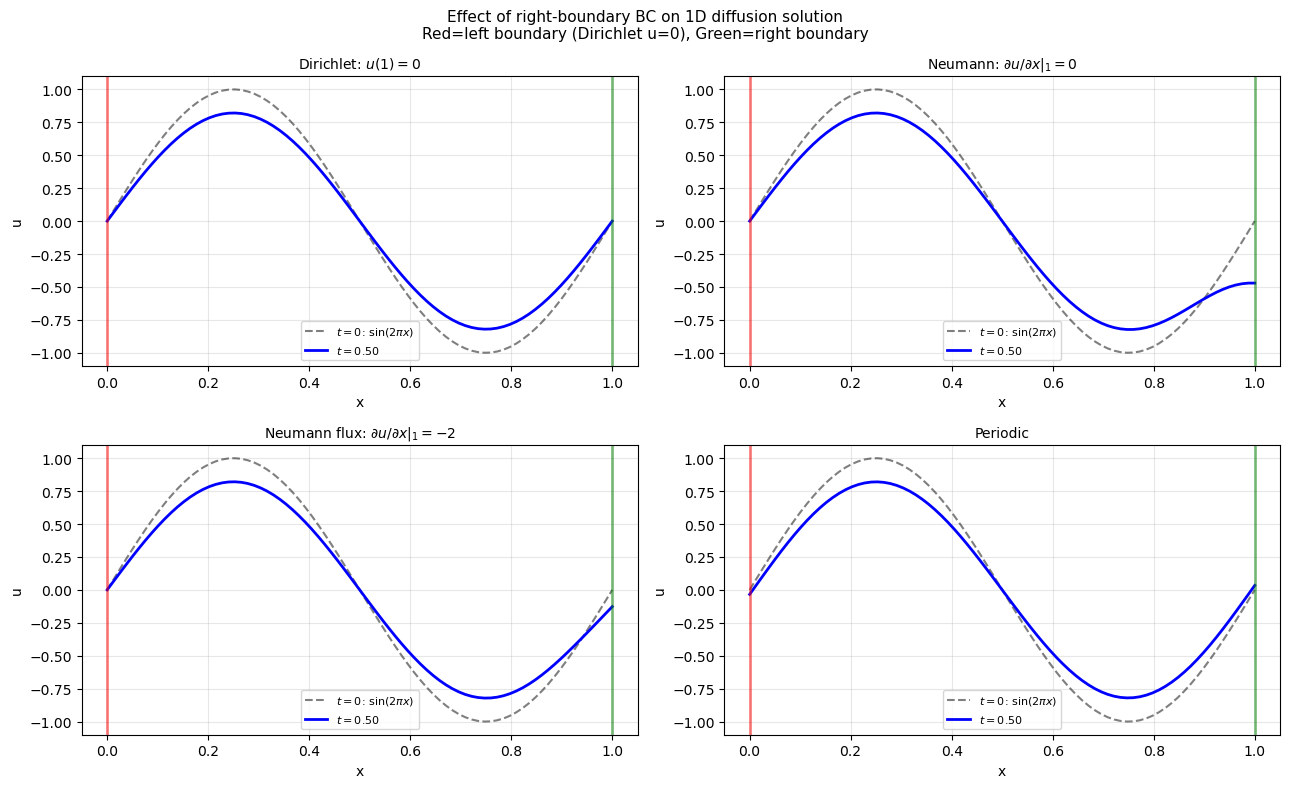

Observations:
  Dirichlet u=0:      solution pinned to zero at right — forced to match
  Neumann du/dx=0:    solution ends with zero slope — free to take any value
  Neumann flux=-2:    solution ends with prescribed slope — controls heat loss
  Periodic:           left and right values match — wave wraps around


In [2]:
# ── Ghost cell mechanics for all four BC types ────────────────────────────────
# Solve 1D diffusion du/dt = α d²u/dx² on [0,1] for T=0.5
# Compare results with different right-boundary BCs

def diffuse_with_bc(N, alpha, dt, nt, left_bc_val, right_bc_type, right_bc_val=0.0):
    """
    left_bc_type: 'dirichlet', value = left_bc_val
    right_bc_type: 'dirichlet' | 'neumann_zero' | 'neumann_flux' | 'periodic'
    """
    dx = 1.0 / (N-1)
    x  = np.linspace(0, 1, N)
    u  = np.sin(2*np.pi*x)   # initial condition

    r = alpha * dt / dx**2
    assert r <= 0.5, f'Unstable: r={r:.3f} > 0.5'

    for _ in range(nt):
        un = u.copy()
        u[1:-1] += r * (un[2:] - 2*un[1:-1] + un[:-2])

        # ── Left BC: Dirichlet u(0) = left_bc_val ────────────────────────────
        u[0] = left_bc_val

        # ── Right BC ─────────────────────────────────────────────────────────
        if right_bc_type == 'dirichlet':
            u[-1] = right_bc_val             # fixed value
        elif right_bc_type == 'neumann_zero':
            u[-1] = u[-2]                    # du/dx=0: ghost = neighbour
        elif right_bc_type == 'neumann_flux':
            u[-1] = u[-2] - 2*dx*right_bc_val   # du/dx = flux at right face
        elif right_bc_type == 'periodic':
            u[-1] = u[1]                     # wrap around
            u[0]  = u[-2]                    # (both ends periodic)
    return x, u

N     = 80
alpha = 0.01
dx    = 1.0 / (N-1)
dt    = 0.4 * dx**2 / alpha
nt    = int(0.5 / dt)

cases = [
    ('Dirichlet: $u(1)=0$',          'dirichlet',    0.0),
    ('Neumann: $\\partial u/\\partial x|_1=0$', 'neumann_zero', 0.0),
    ('Neumann flux: $\\partial u/\\partial x|_1=-2$', 'neumann_flux', -2.0),
    ('Periodic',                      'periodic',     0.0),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, (title, bc_type, bc_val) in zip(axes, cases):
    x0 = np.linspace(0, 1, N)
    u0 = np.sin(2*np.pi*x0)   # initial
    x, u = diffuse_with_bc(N, alpha, dt, nt, 0.0, bc_type, bc_val)

    ax.plot(x0, u0, 'k--', lw=1.5, alpha=0.5, label='$t=0$: $\\sin(2\\pi x)$')
    ax.plot(x, u,   'b-',  lw=2,              label=f'$t={nt*dt:.2f}$')
    ax.axvline(0, color='red', lw=2, alpha=0.5)
    ax.axvline(1, color='green', lw=2, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Effect of right-boundary BC on 1D diffusion solution\n'
             'Red=left boundary (Dirichlet u=0), Green=right boundary', fontsize=11)
plt.tight_layout()
plt.show()

print('Observations:')
print('  Dirichlet u=0:      solution pinned to zero at right — forced to match')
print('  Neumann du/dx=0:    solution ends with zero slope — free to take any value')
print('  Neumann flux=-2:    solution ends with prescribed slope — controls heat loss')
print('  Periodic:           left and right values match — wave wraps around')

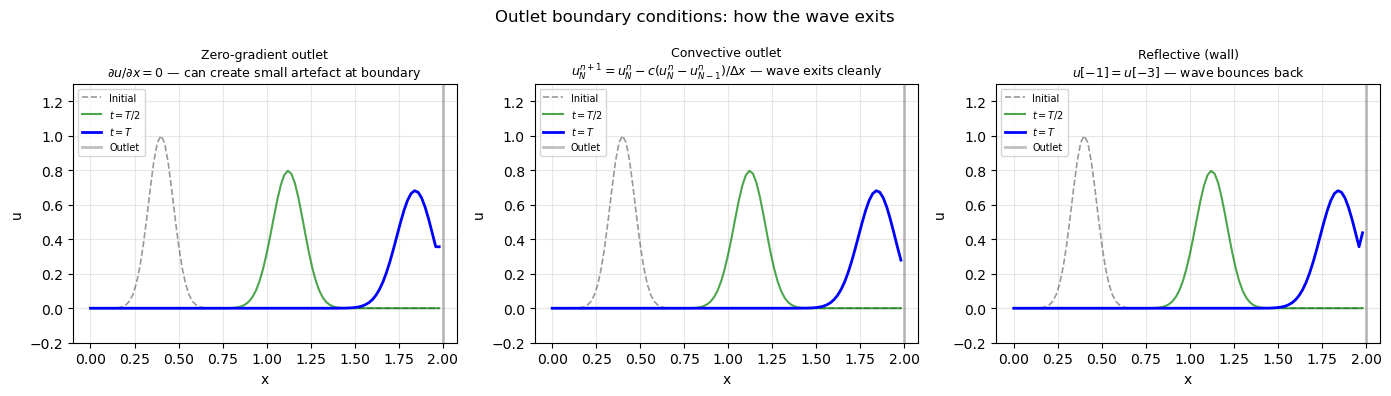

Convective BC is best for outlet: wave exits without reflection.
OpenFOAM: use "inletOutlet" or "zeroGradient" for outlet velocity,
         "fixedValue 0" or "totalPressure" for outlet pressure.


In [3]:
# ── Convective outflow BC vs zero-gradient BC ─────────────────────────────────
# Demonstrate that the convective BC allows waves to exit cleanly,
# while the zero-gradient BC causes reflections.

def advect_with_outlet(u0, c, dx, dt, nt, bc='zero_gradient'):
    """1D advection with different outlet BCs at x=L."""
    u = u0.copy()
    nu = c * dt / dx

    for _ in range(nt):
        un = u.copy()
        # Interior: upwind
        u[1:-1] = un[1:-1] - nu*(un[1:-1]-un[:-2])

        # Left inlet: zero (no wave coming in)
        u[0] = 0.0

        # Right outlet
        if bc == 'zero_gradient':
            u[-1] = u[-2]                          # du/dx=0: simple
        elif bc == 'convective':
            u[-1] = un[-1] - nu*(un[-1]-un[-2])    # advect the wave out
        elif bc == 'reflective':
            u[-1] = u[-3]                          # reflects the wave back
    return u

N  = 100
L  = 2.0
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
c  = 1.0
dt = 0.8 * dx / c
u0 = np.exp(-((x-0.4)**2)/0.01)   # Gaussian blob near inlet
nt = 90   # advance until wave reaches outlet

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bcs    = ['zero_gradient', 'convective', 'reflective']
titles = [
    'Zero-gradient outlet\n$\\partial u/\\partial x=0$ — can create small artefact at boundary',
    'Convective outlet\n$u_N^{n+1} = u_N^n - c(u_N^n-u_{N-1}^n)/\\Delta x$ — wave exits cleanly',
    'Reflective (wall)\n$u[-1]=u[-3]$ — wave bounces back'
]

for ax, bc, title in zip(axes, bcs, titles):
    u_final = advect_with_outlet(u0, c, dx, dt, nt, bc)
    u_mid   = advect_with_outlet(u0, c, dx, dt, nt//2, bc)

    ax.plot(x, u0,      'k--', lw=1.2, alpha=0.4, label='Initial')
    ax.plot(x, u_mid,   'g-',  lw=1.5, alpha=0.7, label='$t=T/2$')
    ax.plot(x, u_final, 'b-',  lw=2,              label='$t=T$')
    ax.axvline(L, color='gray', lw=2, alpha=0.5, label='Outlet')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=7); ax.set_ylim(-0.2, 1.3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Outlet boundary conditions: how the wave exits', fontsize=12)
plt.tight_layout()
plt.show()

print('Convective BC is best for outlet: wave exits without reflection.')
print('OpenFOAM: use "inletOutlet" or "zeroGradient" for outlet velocity,')
print('         "fixedValue 0" or "totalPressure" for outlet pressure.')

## 6. Robin BC — Convective Heat Transfer

$$a\,\phi + b\,\frac{\partial \phi}{\partial n} = c$$

**Example:** wall with Newton's law of cooling:

$$-k\frac{\partial T}{\partial n} = h\,(T_{\text{wall}} - T_\infty)$$

Rearranged: $h\,T + k\,\frac{\partial T}{\partial n} = h\,T_\infty$ — a Robin BC with $a=h$, $b=k$, $c=h\,T_\infty$.

**Ghost cell for Robin:**

$$\text{ghost} = \phi_1 + \frac{(c - a\,\phi_0)\,2\,\Delta x}{b}$$

This will appear in the **heat exchanger project** (Module 4).

## Summary

| BC type | Python | When to use |
|---------|--------|------------|
| Dirichlet | `u[0,:] = value` | Known value: wall, lid, inlet |
| Neumann (zero-grad) | `u[0,:] = u[1,:]` | Unknown value: outlet, insulated wall |
| Neumann (prescribed flux) | `u[0,:] = u[1,:] - 2*dy*flux` | Known flux: heat input, shear-driven |
| Periodic | `u[0,:]=u[-2,:]; u[-1,:]=u[1,:]` | Symmetric/infinite domain |
| Convective outlet | `u[-1] -= nu*(u[-1]-u[-2])` | Exit without reflection |

**The N-S pressure BC rule:**
- At walls (no-slip): always $\partial p/\partial n = 0$ — derived from N-S, not chosen
- At outlet: $p = 0$ — sets the pressure reference
- Never set Dirichlet pressure at a wall — this is physically wrong and will corrupt your velocity

**Module 2 complete.** You now have:
- A complete 2D incompressible N-S solver (SIMPLE/fractional step)
- Validation against Ghia et al. lid-driven cavity benchmark
- External flow over a cylinder with drag/lift computation
- A systematic understanding of all boundary condition types

---
**Next:** Module 3.1 — Turbulence Basics: Reynolds decomposition, RANS equations, and the closure problem. Your solver handles laminar flow; Module 3 extends it to turbulent flows at any Re.